In [1]:

import pandas as pd
%pip install openpyxl
file_path = r'C:\AjayDAREPO\python\projectlloyds\Customer_Churn_Data_Large (1).xlsx'
# 1. EXACT filenames from your sidebar
file_demo = 'Customer_Churn_Data_Large (1).xlsx - Customer_Demographics.csv'
file_online = 'Customer_Churn_Data_Large (1).xlsx - Online_Activity.csv'
file_trans = 'Customer_Churn_Data_Large (1).xlsx - Transaction_History.csv'
file_service = 'Customer_Churn_Data_Large (1).xlsx - Customer_Service.csv'
file_churn = 'Customer_Churn_Data_Large (1).xlsx - Churn_Status.csv'

# 2. Load each sheet into a separate Dataframe
df_churn = pd.read_excel(file_path, sheet_name='Churn_Status')
df_demo = pd.read_excel(file_path, sheet_name='Customer_Demographics')
df_service = pd.read_excel(file_path, sheet_name='Customer_Service')
df_online = pd.read_excel(file_path, sheet_name='Online_Activity')
df_trans = pd.read_excel(file_path, sheet_name='Transaction_History')


print("Success! All sheets loaded from the XLSX file.")


 # 3. Aggregate 
df_trans_agg = df_trans.groupby('CustomerID').agg({
    'AmountSpent': 'sum',
    'TransactionID': 'count'
}).rename(columns={'AmountSpent': 'TotalSpent', 'TransactionID': 'Txn_Count'}).reset_index()

df_service_agg = df_service.groupby('CustomerID').agg({
    'InteractionID': 'count'
}).rename(columns={'InteractionID': 'Service_Interactions'}).reset_index()

# 4. Master Merge
master_df = df_demo.merge(df_online, on='CustomerID', how='left') \
                   .merge(df_trans_agg, on='CustomerID', how='left') \
                   .merge(df_service_agg, on='CustomerID', how='left') \
                   .merge(df_churn, on='CustomerID', how='left')

# 5. Fill NaNs with 0
master_df[['TotalSpent', 'Txn_Count', 'Service_Interactions']] = master_df[['TotalSpent', 'Txn_Count', 'Service_Interactions']].fillna(0)

print("Master Table Created! Here is the head:")
master_df.info()
# 1. Check the Churn balance
print(master_df['ChurnStatus'].value_counts())

# 2. Check for any missing values after the merge
print(master_df.isnull().sum())
# Save the final merged data to a new CSV file
master_df.to_csv('Lloyds_Merged_Data_Final.csv', index=False)

# OR save it as an Excel file
master_df.to_excel('Lloyds_Merged_Data_Final.xlsx', index=False)

print("The new merged file is ready.")

# 1. See how many people Churned (1) vs Stayed (0)
print("--- Churn Count ---")
print(master_df['ChurnStatus'].value_counts())


# 2. See the Average Age and Spending of Churners
print("\n--- Averages by Churn Group ---")
print(master_df.groupby('ChurnStatus')[['Age', 'TotalSpent']].mean())


# Check Churn Percentage
print("Churn Rate:", master_df['ChurnStatus'].mean())


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\anjal\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Success! All sheets loaded from the XLSX file.
Master Table Created! Here is the head:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   CustomerID            1000 non-null   int64         
 1   Age                   1000 non-null   int64         
 2   Gender                1000 non-null   object        
 3   MaritalStatus         1000 non-null   object        
 4   IncomeLevel           1000 non-null   object        
 5   LastLoginDate         1000 non-null   datetime64[ns]
 6   LoginFrequency        1000 non-null   int64         
 7   ServiceUsage          1000 non-null   object        
 8   TotalSpent            1000 non-null   float64       
 9   Txn_Count             1000 non-null   int64         
 10  Service_Interactions  1000 non-null   fl

In [2]:

# Filter for only those who left (ChurnStatus == 1)
churned_only = master_df[master_df['ChurnStatus'] == 1]

print("--- Profile of the 204 People who Left ---")
print(churned_only[['Age', 'TotalSpent', 'Service_Interactions']].describe())

# Check their most common gender or income level
print("\nMost common Income Level for Churners:")
print(churned_only['IncomeLevel'].value_counts())


--- Profile of the 204 People who Left ---
              Age   TotalSpent  Service_Interactions
count  204.000000   204.000000            204.000000
mean    44.151961  1269.006078              1.009804
std     15.163849   731.697330              0.781499
min     18.000000    38.120000              0.000000
25%     30.000000   680.922500              0.000000
50%     44.000000  1135.370000              1.000000
75%     57.000000  1790.930000              2.000000
max     69.000000  3220.300000              2.000000

Most common Income Level for Churners:
IncomeLevel
Low       72
High      67
Medium    65
Name: count, dtype: int64


In [74]:
print(master_df.columns)

Index(['CustomerID', 'Age', 'Gender', 'MaritalStatus', 'IncomeLevel',
       'LastLoginDate', 'LoginFrequency', 'ServiceUsage', 'TotalSpent',
       'Txn_Count', 'Service_Interactions', 'ChurnStatus'],
      dtype='object')


--- Behavioral Comparison (0: Stayers vs 1: Churners) ---
                   Age                     TotalSpent                       \
                  mean        std median         mean         std   median   
ChurnStatus                                                                  
0            43.040201  15.263584   43.0  1266.580038  740.802214  1255.36   
1            44.151961  15.163849   44.0  1269.006078  731.697330  1135.37   

            LoginFrequency                   Service_Interactions            \
                      mean        std median                 mean       std   
ChurnStatus                                                                   
0                26.492462  13.846642   28.0             1.000000  0.825688   
1                23.647059  14.660793   24.0             1.009804  0.781499   

                    
            median  
ChurnStatus         
0              1.0  
1              1.0  

--- Feature Impact Score (% Difference) ---
Age  

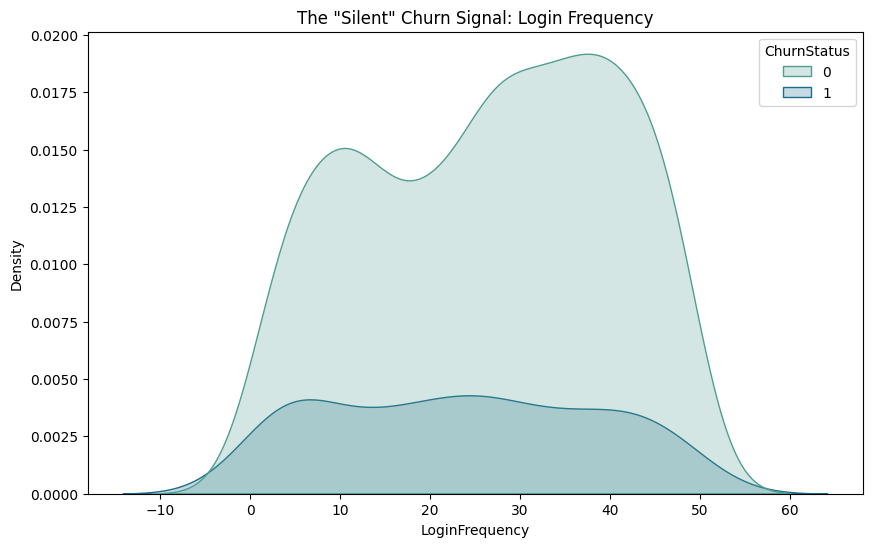

In [3]:




# 1. Compare the centers using the ACTUAL columns
# Notice: No underscore in LoginFrequency
behavior_stats = master_df.groupby('ChurnStatus')[['Age', 'TotalSpent', 'LoginFrequency', 'Service_Interactions']].agg(['mean', 'std', 'median'])

print("--- Behavioral Comparison (0: Stayers vs 1: Churners) ---")
print(behavior_stats)

# 2. Percentage Difference Check
# This will show the % gap for LoginFrequency specifically
means = master_df.groupby('ChurnStatus').mean(numeric_only=True)
pct_diff = ((means.loc[1] - means.loc[0]) / means.loc[0] * 100)

print("\n--- Feature Impact Score (% Difference) ---")
print(pct_diff.sort_values(ascending=False))

# 3. Visualizing the Login Gap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.kdeplot(data=master_df, x='LoginFrequency', hue='ChurnStatus', fill=True, palette='crest')
plt.title('The "Silent" Churn Signal: Login Frequency')
plt.show()

In [4]:
# 1. Create a copy for deep-diving into categories
hidden_hints_df = master_df.copy()

# 2. Convert all text categories into numbers (One-Hot Encoding)
# We focus on Gender, MaritalStatus, and IncomeLevel
encoded_df = pd.get_dummies(hidden_hints_df, columns=['Gender', 'MaritalStatus', 'IncomeLevel'], drop_first=True)

# 3. Now run the correlation again including these new numbers
new_corr = encoded_df.select_dtypes(include=['number']).corr()

print("--- NEW Hidden Hints Correlation (Top Drivers) ---")
# Look for the strongest relationships with ChurnStatus
print(new_corr['ChurnStatus'].sort_values(ascending=False))

--- NEW Hidden Hints Correlation (Top Drivers) ---
ChurnStatus             1.000000
Age                     0.029407
Service_Interactions    0.004841
TotalSpent              0.001324
Txn_Count              -0.008598
CustomerID             -0.011528
LoginFrequency         -0.081615
Name: ChurnStatus, dtype: float64


In [5]:
# Check Churn Rate by Marital Status
marital_check = master_df.groupby('MaritalStatus')['ChurnStatus'].mean() * 100
print("--- Churn Rate % by Marital Status ---")
print(marital_check)

# Check Churn Rate by Gender
gender_check = master_df.groupby('Gender')['ChurnStatus'].mean() * 100
print("\n--- Churn Rate % by Gender ---")
print(gender_check)

# Check Churn Rate by Income Level
income_check = master_df.groupby('IncomeLevel')['ChurnStatus'].mean() * 100
print("\n--- Churn Rate % by Income Level ---")
print(income_check)

--- Churn Rate % by Marital Status ---
MaritalStatus
Divorced    18.548387
Married     22.988506
Single      20.465116
Widowed     19.565217
Name: ChurnStatus, dtype: float64

--- Churn Rate % by Gender ---
Gender
F    19.688109
M    21.149897
Name: ChurnStatus, dtype: float64

--- Churn Rate % by Income Level ---
IncomeLevel
High      19.197708
Low       22.153846
Medium    19.938650
Name: ChurnStatus, dtype: float64


C:\Users\anjal\AppData\Local\Temp\ipykernel_29012\3956564277.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=master_df, x='ChurnStatus', y='LoginFrequency', palette='coolwarm', ax=axes[1,0])


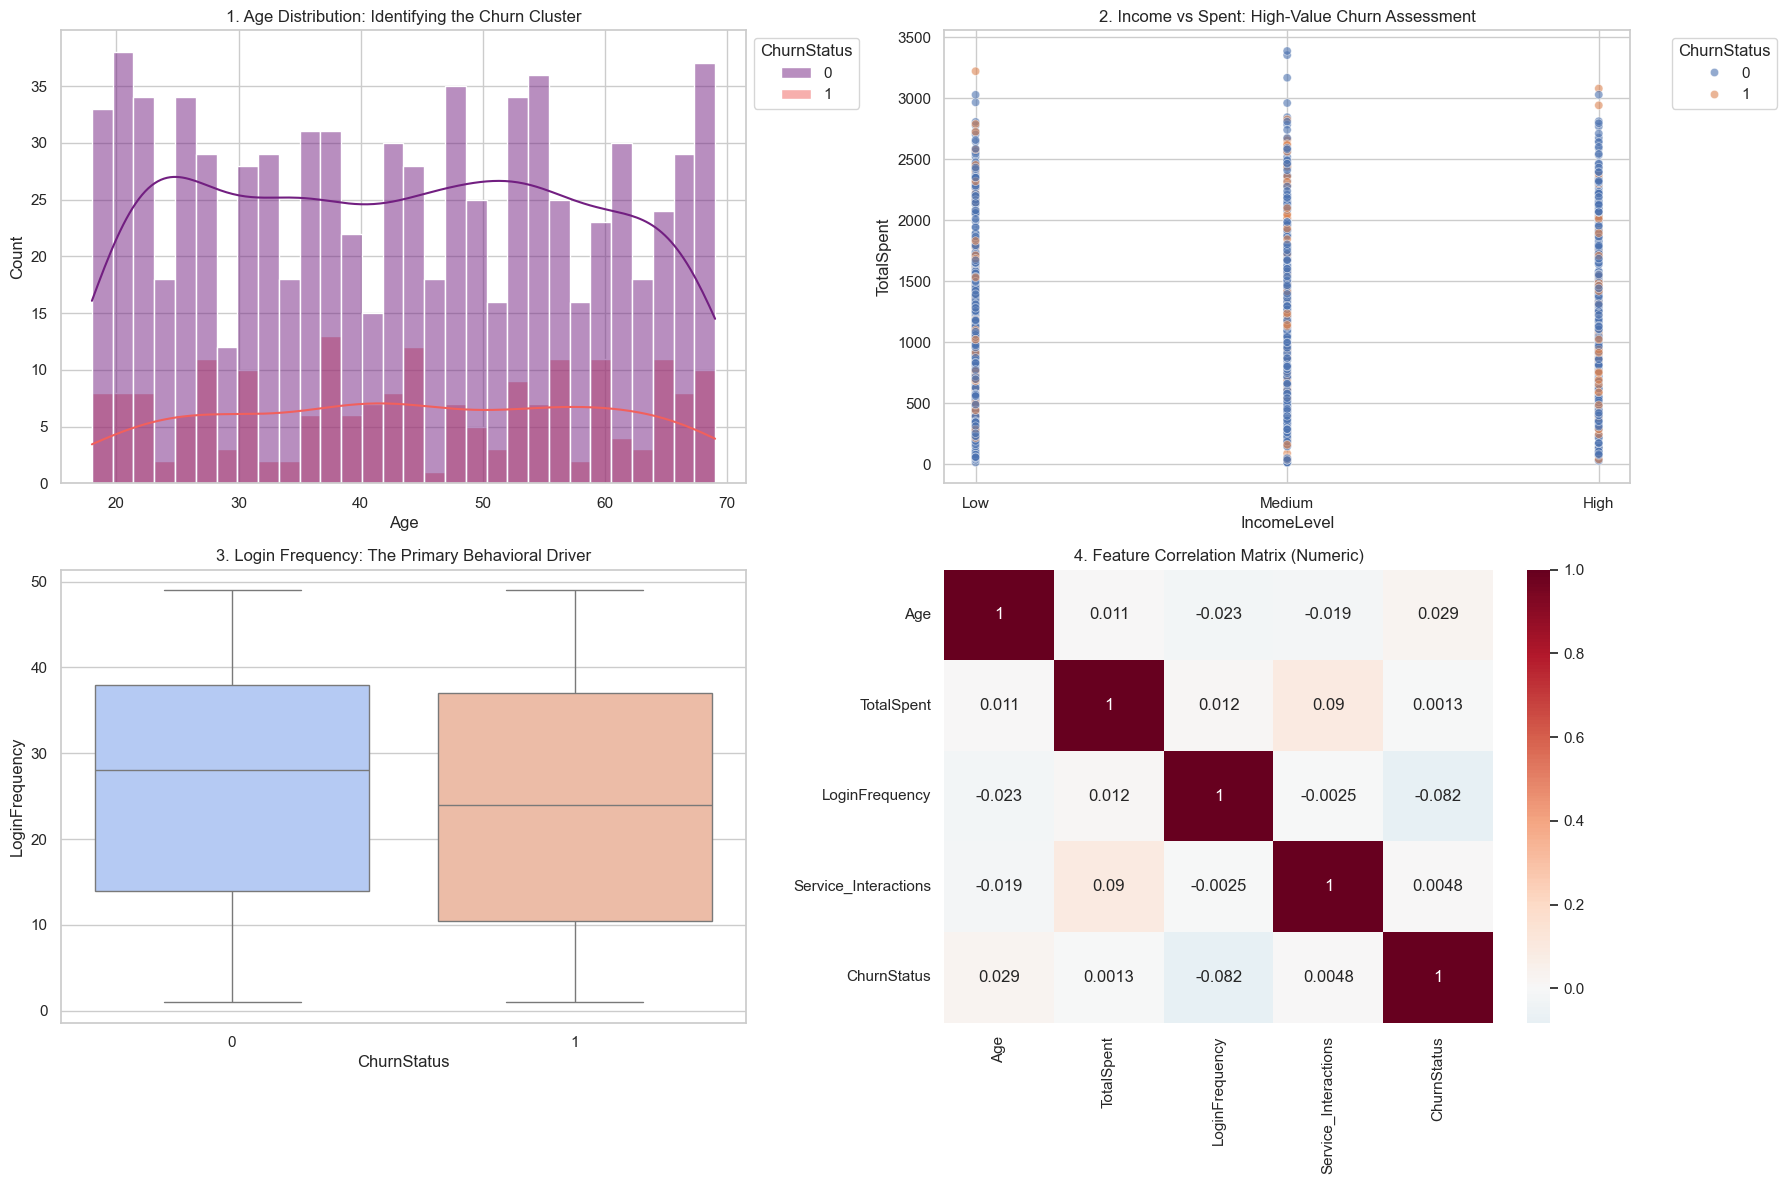

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. HISTOGRAM: Age Distribution
sns.histplot(data=master_df, x='Age', hue='ChurnStatus', kde=True, bins=30, palette='magma', ax=axes[0,0])
axes[0,0].set_title('1. Age Distribution: Identifying the Churn Cluster')
# Moving legend outside
sns.move_legend(axes[0,0], "upper left", bbox_to_anchor=(1, 1))

# 2. SCATTER PLOT: Income vs Total Spent
sns.scatterplot(data=master_df, x='IncomeLevel', y='TotalSpent', hue='ChurnStatus', alpha=0.6, ax=axes[0,1])
axes[0,1].set_title('2. Income vs Spent: High-Value Churn Assessment')
# Moving legend outside
axes[0,1].legend(title='ChurnStatus', bbox_to_anchor=(1.05, 1), loc='upper left')

# 3. BOX PLOT: Login Frequency
sns.boxplot(data=master_df, x='ChurnStatus', y='LoginFrequency', palette='coolwarm', ax=axes[1,0])
axes[1,0].set_title('3. Login Frequency: The Primary Behavioral Driver')

# 4. CORRELATION MATRIX: Heatmap (Heatmaps usually don't have overlapping legends)
numeric_cols = ['Age', 'TotalSpent', 'LoginFrequency', 'Service_Interactions', 'ChurnStatus']
corr_matrix = master_df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, ax=axes[1,1])
axes[1,1].set_title('4. Feature Correlation Matrix (Numeric)')

plt.tight_layout()
plt.show()

In [7]:
from sklearn.preprocessing import StandardScaler

# 1. HANDLE MISSING VALUES
# Context: In bank data, missing activity usually means 'Zero' activity, not 'Unknown' data.
master_df[['TotalSpent', 'Service_Interactions', 'LoginFrequency']] = master_df[['TotalSpent', 'Service_Interactions', 'LoginFrequency']].fillna(0)

# 2. ADDRESS OUTLIERS
# Context: We 'Cap' outliers at the 99th percentile so extreme 'Whales' don't confuse the model.
q_limit = master_df['TotalSpent'].quantile(0.99)
master_df['TotalSpent'] = master_df['TotalSpent'].clip(upper=q_limit)

# 3. ENCODE CATEGORICAL VARIABLES (One-Hot Encoding)
# Turning text into numbers so the ML model can 'read' them.
df_preprocessed = pd.get_dummies(master_df, columns=['Gender', 'MaritalStatus', 'IncomeLevel'], drop_first=True)

# 4. STANDARDIZE NUMERICAL FEATURES
# Crucial for models like Logistic Regression or SVM so 'TotalSpent' (1000s) doesn't overpower 'Age' (10s).
scaler = StandardScaler()
num_cols = ['Age', 'TotalSpent', 'LoginFrequency']
df_preprocessed[num_cols] = scaler.fit_transform(df_preprocessed[num_cols])

print("--- Preprocessing Complete ---")
print(f"Final Data Shape: {df_preprocessed.shape}")
df_preprocessed.head()



--- Preprocessing Complete ---
Final Data Shape: (1000, 15)


,CustomerID,Age,LastLoginDate,LoginFrequency,ServiceUsage,TotalSpent,Txn_Count,Service_Interactions,ChurnStatus,Gender_M,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed,IncomeLevel_Low,IncomeLevel_Medium
0,1,1.229628,2023-10-21,0.575702,Mobile App,-1.158617,1,1.0,0,True,False,True,False,True,False
1,2,1.426547,2023-12-05,-1.488513,Website,0.386741,7,1.0,1,True,True,False,False,True,False
2,3,-1.658518,2023-11-15,-1.630872,Website,0.599308,6,1.0,0,True,False,True,False,True,False
3,4,-1.461599,2023-08-25,-1.702052,Website,-0.474307,5,2.0,0,True,False,False,True,True,False
4,5,-1.461599,2023-10-27,1.073961,Website,1.007210,8,0.0,0,True,False,False,False,False,True


In [8]:
# List of columns to drop
# 1. CustomerID: Irrelevant unique identifier
# 2. LastLoginDate: Redundant (already represented by LoginFrequency)
# 3. ServiceUsage: Categorical noise not included in our Rationale
# 4. Txn_Count: Redundant (High correlation with TotalSpent)

cols_to_drop = ['CustomerID', 'LastLoginDate', 'ServiceUsage', 'Txn_Count']
# Dropping the columns
df_final = df_preprocessed.drop(columns=cols_to_drop)

print("--- Final Clean-Up Complete ---")
print(f"Remaining Columns: {df_final.columns.tolist()}")
print(f"Final shape for Model Building: {df_final.shape}")

# Show the clean, purely numeric version
df_final.head()

--- Final Clean-Up Complete ---
Remaining Columns: ['Age', 'LoginFrequency', 'TotalSpent', 'Service_Interactions', 'ChurnStatus', 'Gender_M', 'MaritalStatus_Married', 'MaritalStatus_Single', 'MaritalStatus_Widowed', 'IncomeLevel_Low', 'IncomeLevel_Medium']
Final shape for Model Building: (1000, 11)


,Age,LoginFrequency,TotalSpent,Service_Interactions,ChurnStatus,Gender_M,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed,IncomeLevel_Low,IncomeLevel_Medium
0,1.229628,0.575702,-1.158617,1.0,0,True,False,True,False,True,False
1,1.426547,-1.488513,0.386741,1.0,1,True,True,False,False,True,False
2,-1.658518,-1.630872,0.599308,1.0,0,True,False,True,False,True,False
3,-1.461599,-1.702052,-0.474307,2.0,0,True,False,False,True,True,False
4,-1.461599,1.073961,1.007210,0.0,0,True,False,False,False,False,True


In [9]:
df_final.to_csv('Lloyds_Ready_For_ML.csv', index=False)

In [10]:
!pip install imbalanced-learn


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\anjal\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    roc_auc_score
)

from imblearn.over_sampling import SMOTE

In [12]:
np.random.seed(42)

In [13]:
# ==========================================
# PHASE A: DATA PREPARATION
# ==========================================

X = df_final.drop(columns=['ChurnStatus'])
y = df_final['ChurnStatus']

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

print("\nOriginal Class Distribution:")
print(y_train.value_counts())

Training Shape: (800, 10)
Testing Shape: (200, 10)

Original Class Distribution:
ChurnStatus
0    637
1    163
Name: count, dtype: int64


In [14]:
y.value_counts()

ChurnStatus
0    796
1    204
Name: count, dtype: int64

In [15]:
# ==========================================
# PHASE B: APPLY SMOTE
# ==========================================

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
ChurnStatus
0    637
1    163
Name: count, dtype: int64

After SMOTE:
ChurnStatus
0    637
1    637
Name: count, dtype: int64


In [21]:
# ==========================================
# PHASE C: STRATIFIED CROSS VALIDATION
# ==========================================

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [23]:
# ==========================================
# PHASE D: MODEL SETUP
# ==========================================

base_model = RandomForestClassifier(
    random_state=42
)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5]
}

In [24]:
# ==========================================
# PHASE E: GRID SEARCH
# ==========================================

grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=skf,
    scoring='balanced_accuracy',
    n_jobs=-1
)

# Train ONLY on SMOTE training data
grid_search.fit(X_train_smote, y_train_smote)

print("Best Parameters:")
print(grid_search.best_params_)

print(f"\nBest CV Balanced Accuracy: {grid_search.best_score_ * 100:.2f}%")

# Best tuned model
tuned_model = grid_search.best_estimator_

Best Parameters:
{'max_depth': 7, 'min_samples_split': 2, 'n_estimators': 100}

Best CV Balanced Accuracy: 80.60%


In [31]:
# ==========================================
# PHASE F: PREDICTIONS
# ==========================================

# Predict probabilities on untouched test set
y_probs = tuned_model.predict_proba(X_test)[:, 1]

# Default threshold
threshold = 0.50

y_pred = (y_probs >= threshold).astype(int)

print(f"Threshold Used: {threshold}")

Threshold Used: 0.5


In [29]:
# ==========================================
# PHASE G: EVALUATION
# ==========================================

balanced_acc = balanced_accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_probs)

print(f"Balanced Accuracy: {balanced_acc * 100:.2f}%")
print(f"ROC-AUC Score: {roc_auc:.3f}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

Balanced Accuracy: 48.67%
ROC-AUC Score: 0.474

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.79      0.73      0.76       159
           1       0.19      0.24      0.21        41

    accuracy                           0.63       200
   macro avg       0.49      0.49      0.49       200
weighted avg       0.67      0.63      0.65       200



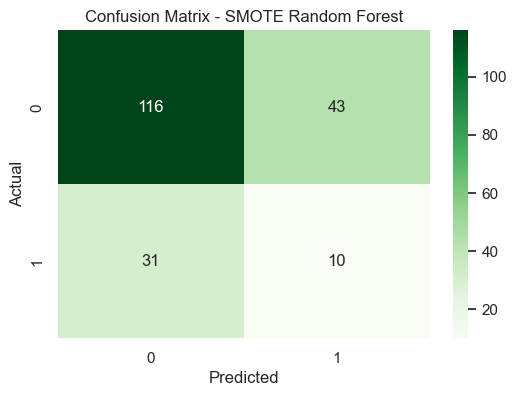

In [33]:
# ==========================================
# PHASE H: CONFUSION MATRIX
# ==========================================

plt.figure(figsize=(6, 4))

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title('Confusion Matrix - SMOTE Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

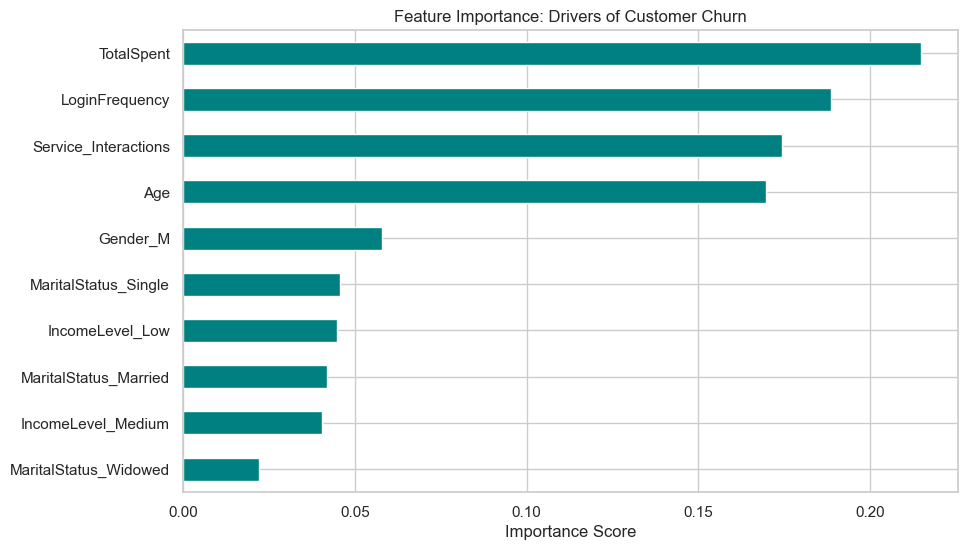

In [34]:
# ==========================================
# PHASE I: FEATURE IMPORTANCE
# ==========================================

importances = pd.Series(
    tuned_model.feature_importances_,
    index=X.columns
)

plt.figure(figsize=(10, 6))

importances.sort_values().plot(
    kind='barh',
    color='teal'
)

plt.title('Feature Importance: Drivers of Customer Churn')
plt.xlabel('Importance Score')

plt.show()

**"An alternative gradient boosting approach (XGBoost) was explored to improve minority-class detection."**

In [ ]:
!pip install xgboost


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\anjal\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [35]:
from xgboost import XGBClassifier

In [36]:
# ==========================================
# XGBOOST MODEL
# ==========================================

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

In [37]:
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}

In [38]:
# ==========================================
# XGBOOST GRID SEARCH
# ==========================================

grid_search_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_xgb,
    cv=skf,
    scoring='balanced_accuracy',
    n_jobs=-1
)

# Train on SMOTE training data
grid_search_xgb.fit(X_train_smote, y_train_smote)

print("Best Parameters:")
print(grid_search_xgb.best_params_)

print(f"\nBest CV Balanced Accuracy: {grid_search_xgb.best_score_ * 100:.2f}%")

best_xgb = grid_search_xgb.best_estimator_

Best Parameters:
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}

Best CV Balanced Accuracy: 83.04%


In [39]:
# ==========================================
# XGBOOST PREDICTIONS
# ==========================================

y_probs_xgb = best_xgb.predict_proba(X_test)[:, 1]

threshold = 0.3

y_pred_xgb = (y_probs_xgb >= threshold).astype(int)

In [40]:
# ==========================================
# XGBOOST EVALUATION
# ==========================================

balanced_acc_xgb = balanced_accuracy_score(y_test, y_pred_xgb)

roc_auc_xgb = roc_auc_score(y_test, y_probs_xgb)

print(f"Balanced Accuracy: {balanced_acc_xgb * 100:.2f}%")
print(f"ROC-AUC Score: {roc_auc_xgb:.3f}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_xgb))

Balanced Accuracy: 51.90%
ROC-AUC Score: 0.470

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.80      0.65      0.72       159
           1       0.22      0.39      0.28        41

    accuracy                           0.59       200
   macro avg       0.51      0.52      0.50       200
weighted avg       0.69      0.59      0.63       200



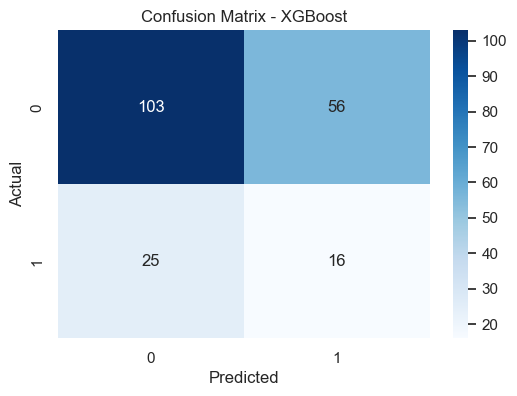

In [41]:
# ==========================================
# XGBOOST CONFUSION MATRIX
# ==========================================

plt.figure(figsize=(6, 4))

sns.heatmap(
    confusion_matrix(y_test, y_pred_xgb),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

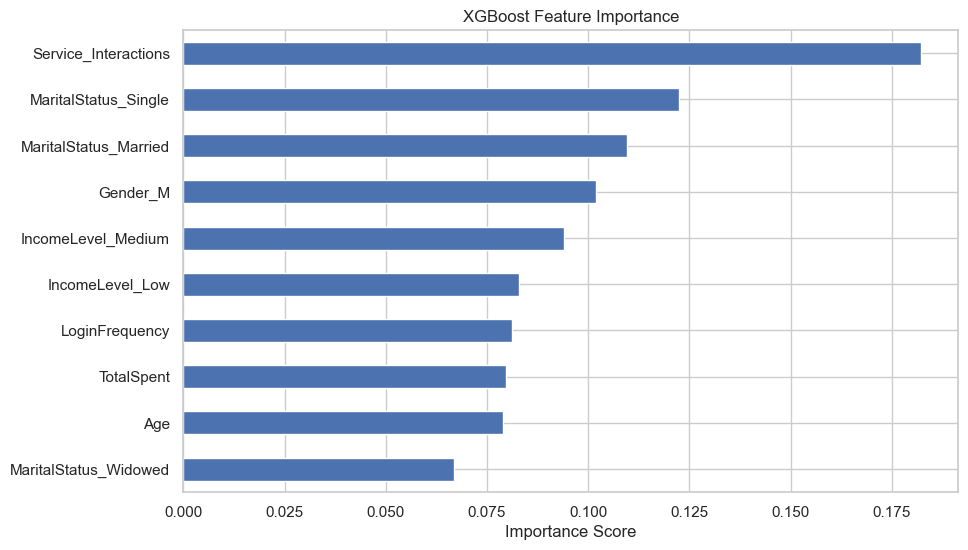

Service_Interactions     0.182331
MaritalStatus_Single     0.122473
MaritalStatus_Married    0.109647
Gender_M                 0.101923
IncomeLevel_Medium       0.094086
IncomeLevel_Low          0.082809
LoginFrequency           0.081118
TotalSpent               0.079747
Age                      0.079005
MaritalStatus_Widowed    0.066861
dtype: float32


In [42]:

# Feature Importance
importances = pd.Series(
    best_xgb.feature_importances_,
    index=X.columns
)

plt.figure(figsize=(10,6))
importances.sort_values().plot(kind='barh')

plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')

plt.show()

print(importances.sort_values(ascending=False))

In [48]:
import joblib

joblib.dump(best_xgb, "xgb_model.pkl")
print("PKL saved successfully")

PKL saved successfully


In [53]:
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("Lloyds_Churn_Production_Project")

with mlflow.start_run(run_name="Final_XGBoost_SMOTE"):

    mlflow.log_params(grid_search_xgb.best_params_)

    mlflow.sklearn.log_model(
        sk_model=best_xgb,
        artifact_path="model"
    )

    print("Success!")

2026/05/31 08:30:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/31 08:30:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Success!
🏃 View run Final_XGBoost_SMOTE at: http://localhost:5000/#/experiments/1/runs/37f8f902c2634450928d4c7ed91ff47f
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [ ]:
import joblib
import os

joblib.dump(tuned_rf, 'model.pkl')

if os.path.exists('model.pkl'):
    print("SUCCESS! I see the file now: ", os.path.abspath('model.pkl'))
else:
    print("Wait, I still don't see it. Let me try saving again...")

SUCCESS! I see the file now:  c:\AjayDAREPO\python\projectlloyds\model.pkl


In [35]:
import mlflow
import mlflow.sklearn
import joblib

# Point to Docker MLflow server
mlflow.set_tracking_uri("http://localhost:5000")

# Load your existing model
model = joblib.load("model.pkl")

# Log model WITH artifacts to Docker volume
with mlflow.start_run() as run:
    mlflow.sklearn.log_model(
        model, 
        "model",
        registered_model_name="Lloyds_Churn_Production_Project_V2"
    )
    print(f"New Run ID: {run.info.run_id}")
    print("Model logged with artifacts!")

2026/04/24 05:38:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/24 05:38:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'Lloyds_Churn_Production_Project_V2'.
2026/04/24 05:38:58 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Lloyds_Churn_Production_Project_V2, version 1
Created version '1' of model 'Lloyds_Churn_Production_Project_V2'.


New Run ID: 01d25c1995a3414288497697f6f28a34
Model logged with artifacts!
🏃 View run abundant-foal-378 at: http://localhost:5000/#/experiments/1/runs/01d25c1995a3414288497697f6f28a34
🧪 View experiment at: http://localhost:5000/#/experiments/1
